In [1]:
import os
import numpy as np
import scipy.io as sio
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import ancillary as ac
from sklearn.svm import LinearSVC
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import hdmedians as hd
from utils import correlation, calculate_mcc, age_regression, sex_classification, plot_sq, convert_pvalue, pvalue_to_r
from scipy import stats
from scipy.stats import pearsonr

In [2]:
res_dir = "/data/users4/xli/MSIVA/MSIVA/results"
ukb_smri_data_path = os.path.join(res_dir, "mat", "UKB_MMIVA_C30_preregSite_SMRI_MancovanOuts_wX_FINAL.mat")
ukb_smri_data = sio.loadmat(ukb_smri_data_path)["MODELUKB0s_ful"]
ukb_smri_data_array = ukb_smri_data[0][0][0]
ukb_smri_data_key = np.squeeze(ukb_smri_data[0][0][3])
age_idx = np.where(ukb_smri_data_key==["age_when_attended_assessment_centre_f21003_2_0"])[0][0]
sex_idx = np.where(ukb_smri_data_key==["sex_f31_0_0"])[0][0]
age = ukb_smri_data_array[:, age_idx]
sex = ukb_smri_data_array[:, sex_idx]

In [ ]:
img_dir = os.path.join(res_dir, "img")
subspace_struct_list = ["s1", "s2", "s3", "s4", "s5"]
num_subspace_struct = len(subspace_struct_list)

Y = np.zeros((num_subspace_struct,3,2,12,2907)) # S1-5, uimodal/MSIVA/multimodal, M1-2, voxel, source
W = np.zeros((num_subspace_struct,3,2,12,44318)) # S1-5, uimodal/MSIVA/multimodal, M1-2, voxel, source

num_iter = 21
corr = np.zeros((num_subspace_struct,9,12,12))

for i, ss in enumerate(subspace_struct_list):
    data = sio.loadmat(os.path.join(img_dir, ss, "um_neuroimaging_Y.mat"))
    Y1 = np.squeeze(data['Y1'])

    data = sio.loadmat(os.path.join(img_dir, ss, "ummm_neuroimaging_Y.mat"))
    Y2 = np.squeeze(data['Y2'])

    data = sio.loadmat(os.path.join(img_dir, ss, "mm_neuroimaging_Y.mat"))
    Y3 = np.squeeze(data['Y3'])

    Y[i,0,0] = Y1[0]
    Y[i,0,1] = Y1[1]
    Y[i,1,0] = Y2[0]
    Y[i,1,1] = Y2[1]
    Y[i,2,0] = Y3[0]
    Y[i,2,1] = Y3[1]

    # for j in range(2):
    #     for k in range(2):
    #         for l in range(12):
    #             sgn = np.sign(correlation(Y[i,j,k,l],age))
    #             Y[i,j,k,l] = -sgn * Y[i,j,k,l]

    data = sio.loadmat(os.path.join(img_dir, ss, "um_neuroimaging_W.mat"))
    W1 = np.squeeze(data['W1'])

    data = sio.loadmat(os.path.join(img_dir, ss, "ummm_neuroimaging_W.mat"))
    W2 = np.squeeze(data['W2'])

    data = sio.loadmat(os.path.join(img_dir, ss, "mm_neuroimaging_W.mat"))
    W3 = np.squeeze(data['W3'])

    W[i,0,0] = W1[0]
    W[i,0,1] = W1[1]
    W[i,1,0] = W2[0]
    W[i,1,1] = W2[1]
    W[i,2,0] = W3[0]
    W[i,2,1] = W3[1]

    corr[i,0] = np.corrcoef(Y1[0], Y1[0])[:12,:12]
    corr[i,1] = np.corrcoef(Y1[1], Y1[1])[:12,:12]
    corr[i,2] = np.corrcoef(Y1[0], Y1[1])[12:,:12]

    corr[i,3] = np.corrcoef(Y2[0], Y2[0])[:12,:12]
    corr[i,4] = np.corrcoef(Y2[1], Y2[1])[:12,:12]
    corr[i,5] = np.corrcoef(Y2[0], Y2[1])[12:,:12]

    corr[i,6] = np.corrcoef(Y3[0], Y3[0])[:12,:12]
    corr[i,7] = np.corrcoef(Y3[1], Y3[1])[:12,:12]
    corr[i,8] = np.corrcoef(Y3[0], Y3[1])[12:,:12]

In [4]:
val = 1
num_source = 12

# S1
num_unique_source = 3
s1 = np.zeros((num_source, num_source))
s1[:2,:2] = val
s1[2:5,2:5] = val*2
s1[5:9,5:9] = val*3

# S2
num_unique_source = 2
s2 = np.zeros((num_source, num_source))
s2[:2,:2] = val
s2[2:4,2:4] = val*2
s2[4:6,4:6] = val*3
s2[6:8,6:8] = val*4
s2[8:10,8:10] = val*5

# S3
num_unique_source = 3
s3 = np.zeros((num_source, num_source))
s3[:3,:3] = val
s3[3:6,3:6] = val*2
s3[6:9,6:9] = val*3

# S4
num_unique_source = 4
s4 = np.zeros((num_source, num_source))
s4[:4,:4] = val
s4[4:8,4:8] = val*2

# S5
num_unique_source = 4
s5 = np.zeros((num_source, num_source))
for i in range(12):
    s5[i,i] = val*(i+1)

s_list = [s1, s2, s3, s4, s5]

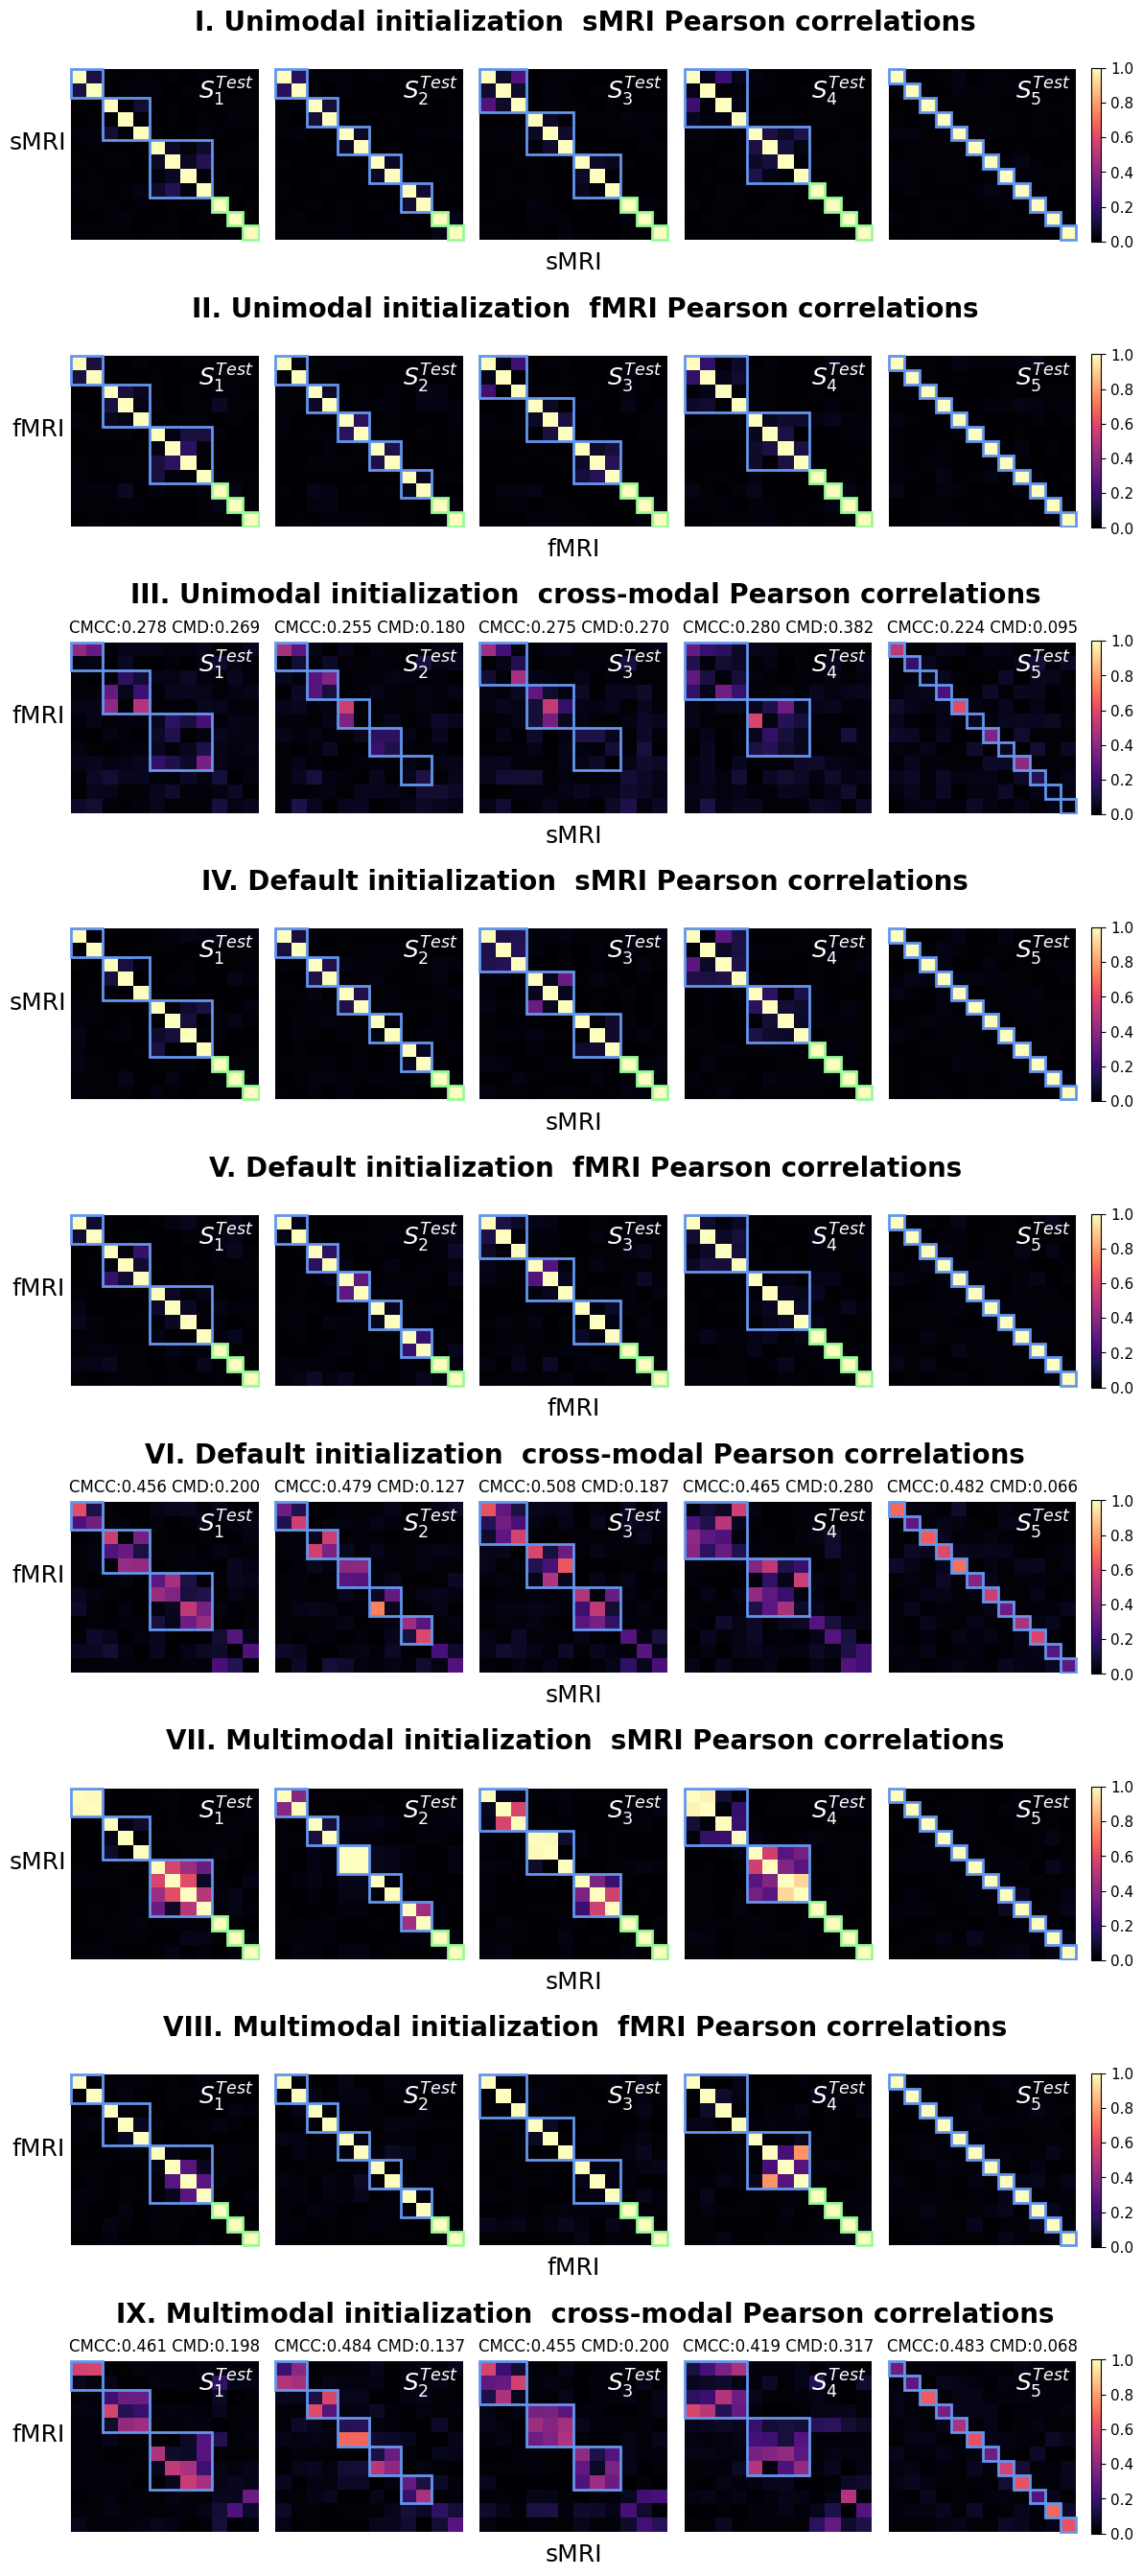

In [ ]:
analysis_list = ["I. Unimodal initialization  sMRI Pearson correlations",
                 "II. Unimodal initialization  fMRI Pearson correlations",
                 "III. Unimodal initialization  cross-modal Pearson correlations",
                 "IV. Default initialization  sMRI Pearson correlations",
                 "V. Default initialization  fMRI Pearson correlations",
                 "VI. Default initialization  cross-modal Pearson correlations",
                 "VII. Multimodal initialization  sMRI Pearson correlations",
                 "VIII. Multimodal initialization  fMRI Pearson correlations",
                 "IX. Multimodal initialization  cross-modal Pearson correlations"]
modality_list = ["sMRI", "fMRI"]
subspace_dict = {"S1": [2, 3, 4], "S2": [2, 2, 2, 2, 2], "S3": [3, 3, 3], "S4": [4, 4], "S5": [1]*12}

n_row = 9

fig, axes = plt.subplots(n_row, num_subspace_struct + 1, figsize = (2.4 * num_subspace_struct, 3 * n_row), gridspec_kw = {'width_ratios': [1, 1, 1, 1, 1, 0.05]})

for i in range(num_subspace_struct):
    ss = subspace_dict[f"S{i+1}"]
    for j in range(n_row):
        ax = axes[j,i]
        abscorr = np.abs(corr[i,j])
        if j in [2, 5, 8]:
            mcc, md, aggcorr, _ = calculate_mcc(abscorr, ss, sort=False)
            sns.heatmap(abscorr, cmap="magma", vmin=0, vmax=1, ax=ax, cbar=False)
            ax.text(9.9, 1.6, f"$S_{i+1}^{{Test}}$", fontsize=18, color="white", ha="center", va="center")
            ax.set_title(f"CMCC:{mcc:.3f} CMD:{md:.3f}", fontsize=12)
            if i == 2:
              ax.set_xlabel("sMRI", fontsize=18)
            if i == 0:
              ax.set_ylabel("fMRI", fontsize=18, rotation=0, labelpad=20)
            plot_sq(ax, i, crossmodal=True)
            ax.set_xlim(-0.1, 12.1)
            ax.set_ylim(12.1, -0.1)
        else:
            mcc = np.mean(np.diag(abscorr))
            sns.heatmap(abscorr, cmap="magma", vmin=0, vmax=1, ax=ax, cbar=False)
            ax.text(9.9, 1.6, f"$S_{i+1}^{{Test}}$", fontsize=18, color="white", ha="center", va="center")
            if i == 2:
               ax.set_xlabel(f"{modality_list[j%3]}", fontsize=18)
            if i == 0:
              ax.set_ylabel(f"{modality_list[j%3]}", fontsize=18, rotation=0, labelpad=20)
            plot_sq(ax, i)
            ax.set_xlim(-0.1, 12.1)
            ax.set_ylim(12.1, -0.1)
        ax.set_xticks([])
        ax.set_yticks([])

norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap="magma", norm=norm)

for i in range(n_row):
    ax = fig.add_subplot(n_row, 1, i+1)
    ax.set_title(analysis_list[i], fontsize=20, fontweight='bold', pad=28)
    ax.axis('off')
    cbar = fig.colorbar(sm, cax=axes[i, 5])
    cbar.ax.tick_params(labelsize=11)

plt.tight_layout(pad=1, h_pad=0, w_pad=1)
plt.savefig("figures/neuroimaging_ukb.pdf")

In [6]:
A = sio.loadmat(os.path.join(res_dir, "mat", "A.mat"))["A"]

WAY_list = []
cca_corr_list = []

for i in np.arange(0,10,2):
    # S1-4, UA/MSIVA, M1-2, voxel, source
    A1 = A[1,1,0,:,i:i+2] # structure 2, MSIVA, M1
    A2 = A[1,1,1,:,i:i+2] # structure 2, MSIVA, M2
    Y1 = Y[1,1,0,i:i+2] 
    Y2 = Y[1,1,1,i:i+2] 
    AY1 = A1@Y1
    AY2 = A2@Y2

    # PCA AY1, AY2
    AY1_p, AY1_p_projM, AY1_p_projM_std = ac.base_PCA(AY1, num_PC=None, axis=-2, whitening=True)
    AY2_p, AY2_p_projM, AY2_p_projM_std = ac.base_PCA(AY2, num_PC=None, axis=-2, whitening=True)

    # Post-PCA eigenvalue problem for CCA
    S12 = AY1_p @ AY2_p.T
    Z1 = np.zeros((AY1_p.shape[0],AY1_p.shape[0]), dtype=AY1_p.dtype)
    Z2 = np.zeros((AY2_p.shape[0],AY2_p.shape[0]), dtype=AY2_p.dtype)
    J = np.block([[Z1, S12],[S12.T, Z2]])
    U, S = ac.do_cov_EVD(J, k=2) # here, k = smallest subspace size in each modality

    # Final transformations: these multiply AY
    W1 = U[:2,].T @ AY1_p_projM
    W2 = U[2:,].T @ AY2_p_projM

    WAY1 = W1 @ AY1 # M1
    WAY2 = W2 @ AY2 # M2
    WAY_list.append([WAY1, WAY2])

    cca_corr = np.corrcoef(WAY1, WAY2)[2:,0:2]
    cca_corr_list.append(cca_corr)

In [7]:
num_voxel = A.shape[3]
num_crossmodal_subspace = 5
voxelwise_cca_corr = np.zeros((num_crossmodal_subspace, num_voxel))

for j, i in enumerate(np.arange(0,10,2)):
    A1 = A[1,1,0,:,i:i+2] # structure 2, MSIVA, M1
    A2 = A[1,1,1,:,i:i+2] # structure 2, MSIVA, M2
    Y1 = Y[1,1,0,i:i+2] 
    Y2 = Y[1,1,1,i:i+2] 
    AY1 = A1@Y1
    AY2 = A2@Y2

    for k in range(num_voxel):
        AY1_voxel = np.expand_dims(AY1[k, :], axis=0)
        AY2_voxel = np.expand_dims(AY2[k, :], axis=0)

        # PCA AY1, AY2
        AY1_p, AY1_p_projM, AY1_p_projM_std = ac.base_PCA(AY1_voxel, num_PC=None, axis=-2, whitening=True)
        AY2_p, AY2_p_projM, AY2_p_projM_std = ac.base_PCA(AY2_voxel, num_PC=None, axis=-2, whitening=True)

        # Post-PCA eigenvalue problem for CCA
        S12 = AY1_p @ AY2_p.T
        Z1 = np.zeros((AY1_p.shape[0],AY1_p.shape[0]), dtype=AY1_p.dtype)
        Z2 = np.zeros((AY2_p.shape[0],AY2_p.shape[0]), dtype=AY2_p.dtype)
        J = np.block([[Z1, S12], [S12.T, Z2]])
        U, S = ac.do_cov_EVD(J, k=2) # here, k = smallest subspace size in each modality

        # Final transformations: these multiply AY
        W1 = U[:1,].T @ AY1_p_projM
        W2 = U[1:,].T @ AY2_p_projM
        WAY1 = W1 @ AY1_voxel
        WAY2 = W2 @ AY2_voxel
        voxelwise_cca_corr[j, k] = np.corrcoef(WAY1, WAY2)[2:,0:2][0,0]

# sio.savemat(os.path.join(res_dir, "mat", "voxelwise_cca_corr_ukb.mat"), {"corr": voxelwise_cca_corr})

In [8]:
regularizer_range = np.linspace(0.1, 1, 10)
param_grid_rr = [{'alpha': regularizer_range}]
param_grid_svm = [{'C': regularizer_range}]

age_mae = np.zeros(5)
age_coef = np.zeros((5, 4))
sex_acc = np.zeros(5)
sex_coef = np.zeros((5, 4))

for i in range(5):
    X12 = (np.concatenate((WAY_list[i][0], WAY_list[i][1]), axis=0)).T # S1M1, S2M1, S1M2, S2M2

    X_train, X_test, y_train, y_test = train_test_split(X12, age, test_size=0.312, random_state=42, stratify=age)
    base_estimator = Ridge()
    rr = GridSearchCV(base_estimator, param_grid_rr, cv=10).fit(X_train, y_train)
    mae, coef = age_regression(X_train, X_test, y_train, y_test, a=rr.best_params_['alpha'])
    age_mae[i] = mae
    age_coef[i] = coef

    X_train, X_test, y_train, y_test = train_test_split(X12, sex, test_size=0.312, random_state=42, stratify=sex)
    base_estimator = LinearSVC(dual=False)
    svc = GridSearchCV(base_estimator, param_grid_svm, cv=10).fit(X_train, y_train)
    acc, coef = sex_classification(X_train, X_test, y_train, y_test, c=svc.best_params_['C'])
    sex_acc[i] = acc * 100
    sex_coef[i] = coef[0]

    print(f"Subspace {i+1}: age regression MAE {age_mae[i]:.3f}; sex classification accuracy {sex_acc[i]:.3f}")

Subspace 1: age regression MAE 5.674; sex classification accuracy 59.542
Subspace 2: age regression MAE 6.163; sex classification accuracy 64.496
Subspace 3: age regression MAE 5.892; sex classification accuracy 59.206
Subspace 4: age regression MAE 5.847; sex classification accuracy 79.933
Subspace 5: age regression MAE 5.378; sex classification accuracy 52.699


/home/users/xli77/anaconda3/envs/icebeem/lib/python3.7/site-packages/ipykernel_launcher.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


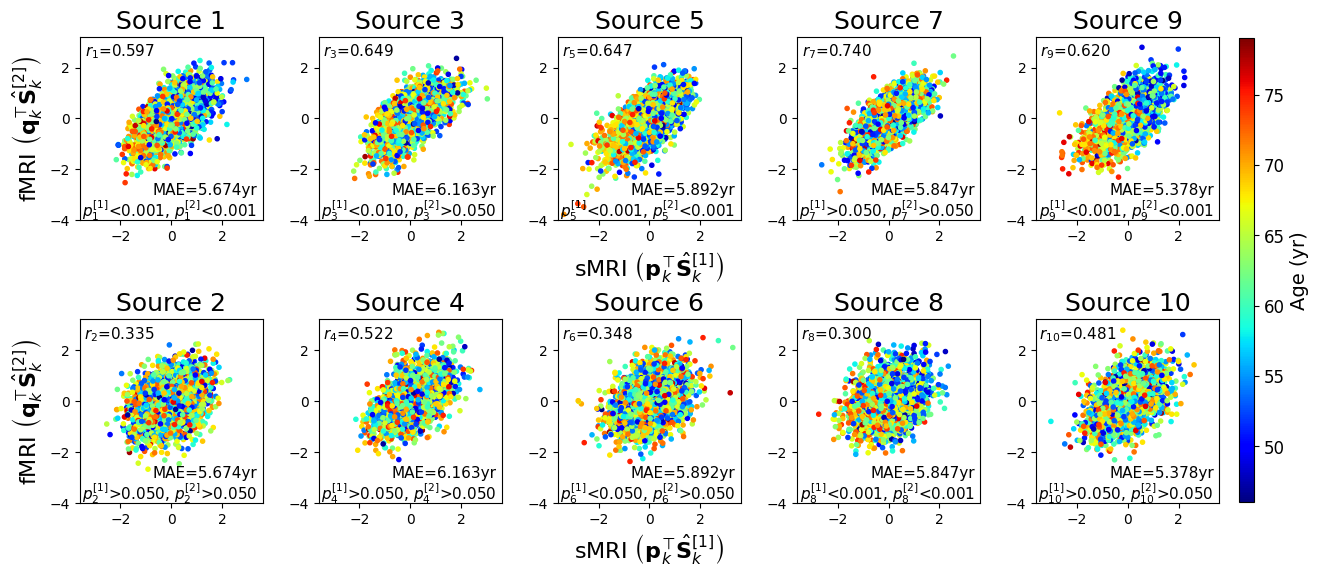

In [ ]:
num_subject = len(age)
age_median = np.median(age)

cmap = plt.cm.jet
norm = Normalize(vmin=age.min(), vmax=age.max())

lim = 3.6
fig, axes = plt.subplots(2,5,figsize=(12.5,5.8))

for k in range(5):
    # check standard deviation
    WAY1 = WAY_list[k][0]
    WAY2 = WAY_list[k][1]
    sign1 = np.sign(correlation(WAY1,age))
    sign2 = np.sign(correlation(WAY2,age))
    for j in range(2):
        WAY1[j,:] = -sign1[j]*WAY1[j,:]
        WAY2[j,:] = -sign2[j]*WAY2[j,:]
    for i in range(2):
        axes[i,k].set_aspect('equal', 'box')
        if k == 2:
            axes[i,k].set_xlabel('sMRI $\\left(\mathbf{{p}}_k^\\top \hat{\mathbf{S}}_k^{[1]}\\right)$', fontsize=16)
        if k == 0:
            axes[i,k].set_ylabel('fMRI $\\left(\mathbf{{q}}_k^\\top \hat{\mathbf{S}}_k^{[2]}\\right)$', fontsize=16)
        axes[i,k].set_title(f'Source {2*k+i+1}', fontsize=18)
        axes[i,k].set_xlim([-lim,lim])
        axes[i,k].set_ylim([-lim-0.4,lim-0.4])
        r = format(round(cca_corr_list[k][i,i],3), '.3f')
        stat1, p1 = stats.ttest_ind(WAY1[i][age<age_median], WAY1[i][age>=age_median])
        stat2, p2 = stats.ttest_ind(WAY2[i][age<age_median], WAY2[i][age>=age_median])
        p1_str = convert_pvalue(p1*20) # correct for 20 comparisons (5 subspaces x 2 sources x 2 modalities)
        p2_str = convert_pvalue(p2*20)
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$r_{{10}}$={r}', xy=(58, 128), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$r_{2*k+i+1}$={r}', xy=(54, 128), xycoords='axes points', size=11, ha='right', va='top')
        axes[i,k].annotate(f'MAE={age_mae[k]:.3f}yr', xy=(128, 27), xycoords='axes points', size=11, ha='right', va='top')
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$p^{{[1]}}_{{10}}${p1_str}, $p^{{[2]}}_{{10}}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$p^{{[1]}}_{2*k+i+1}${p1_str}, $p^{{[2]}}_{2*k+i+1}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        age_subplot = axes[i,k].scatter(WAY1[i], WAY2[i], c=age, cmap=cmap, norm=norm, marker='.', alpha=1)

cbar_ax = fig.add_axes([0.995, 0.13, 0.012, 0.8])
cbar = plt.colorbar(age_subplot, cax=cbar_ax)
cbar.set_label('Age (yr)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("figures/cca_age_ukb.png", bbox_inches='tight', dpi=2000)

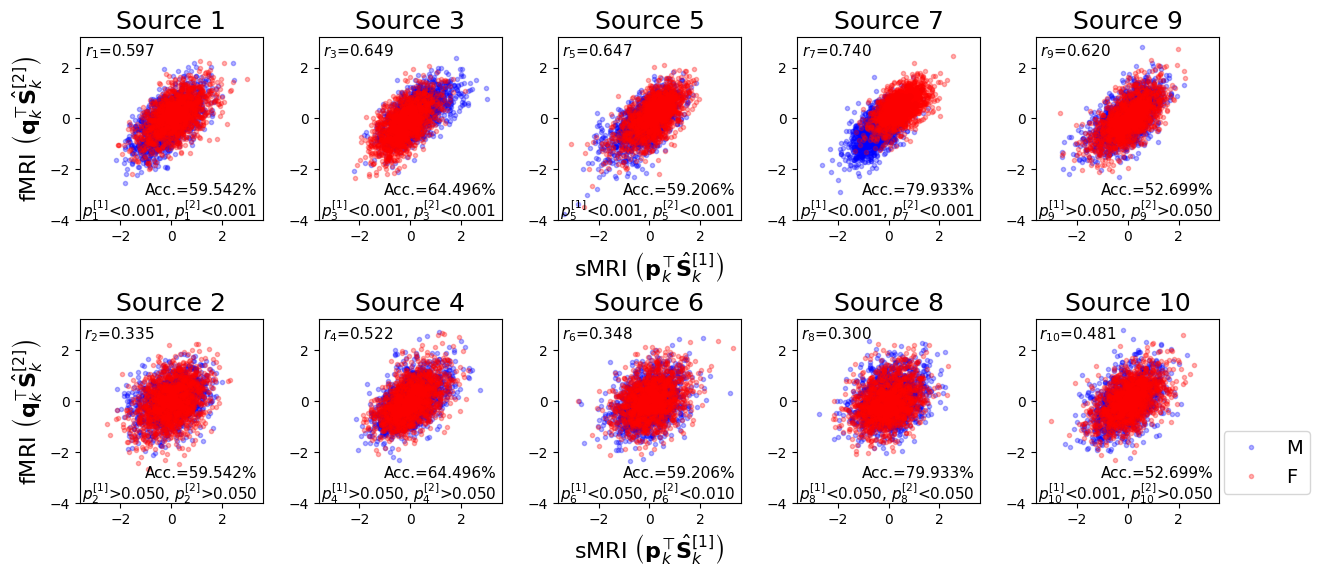

In [ ]:
lim = 3.6
fig, axes = plt.subplots(2,5,figsize=(12.5,5.8))

for k in range(5):
    WAY1 = WAY_list[k][0]
    WAY2 = WAY_list[k][1]
    sign1 = np.sign(correlation(WAY1,age))
    sign2 = np.sign(correlation(WAY2,age))
    for j in range(2):
        WAY1[j,:] = -sign1[j]*WAY1[j,:]
        WAY2[j,:] = -sign2[j]*WAY2[j,:]
    for i in range(2):
        axes[i,k].set_aspect('equal', 'box')
        if k == 2:
            axes[i,k].set_xlabel('sMRI $\\left(\mathbf{{p}}_k^\\top \hat{\mathbf{S}}_k^{[1]}\\right)$', fontsize=16)
        if k == 0:
            axes[i,k].set_ylabel('fMRI $\\left(\mathbf{{q}}_k^\\top \hat{\mathbf{S}}_k^{[2]}\\right)$', fontsize=16)
        axes[i,k].set_title(f'Source {2*k+i+1}', fontsize=18)
        axes[i,k].set_xlim([-lim,lim])
        axes[i,k].set_ylim([-lim-0.4,lim-0.4])
        r = format(round(cca_corr_list[k][i,i],3), '.3f')
        stat1, p1 = stats.ttest_ind(WAY1[i][sex==0], WAY1[i][sex==1])
        stat2, p2 = stats.ttest_ind(WAY2[i][sex==0], WAY2[i][sex==1])
        p1_str = convert_pvalue(p1*20) # correct for 20 comparisons
        p2_str = convert_pvalue(p2*20)
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$r_{{10}}$={r}', xy=(58, 128), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$r_{2*k+i+1}$={r}', xy=(54, 128), xycoords='axes points', size=11, ha='right', va='top')
        axes[i,k].annotate(f'Acc.={sex_acc[k]:.3f}%', xy=(128, 27), xycoords='axes points', size=11, ha='right', va='top')
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$p^{{[1]}}_{{10}}${p1_str}, $p^{{[2]}}_{{10}}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$p^{{[1]}}_{2*k+i+1}${p1_str}, $p^{{[2]}}_{2*k+i+1}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        if k==0 and i==0:
            axes[i,k].plot(WAY1[i][sex==0], WAY2[i][sex==0],'b.',alpha=0.3,label='M')
            axes[i,k].plot(WAY1[i][sex==1], WAY2[i][sex==1],'r.',alpha=0.3,label='F')
        else:
            axes[i,k].plot(WAY1[i][sex==0], WAY2[i][sex==0],'b.',alpha=0.3)
            axes[i,k].plot(WAY1[i][sex==1], WAY2[i][sex==1],'r.',alpha=0.3)

fig.legend(bbox_to_anchor=(1.06, 0.27), fontsize=14)

plt.tight_layout()
plt.savefig("figures/cca_sex_ukb.png", bbox_inches='tight', dpi=2000)

In [11]:
# M1-2, S1-5, median/young/old/male/female, voxel
age_median = np.median(age)
AY_median = np.zeros((2, 5, 5, 44318))
for s, i in enumerate(np.arange(0,10,2)):
    for m in range(2):
        Am = A[1,1,m,:,i:i+2]
        Ym = Y[1,1,m,i:i+2]
        AYm = Am@Ym
        AYm_young = AYm[:,age<age_median]
        AYm_old = AYm[:,age>=age_median]
        AYm_male = AYm[:,sex==0]
        AYm_female = AYm[:,sex==1]
        AYm_median = hd.geomedian(AYm,axis=1)
        AYm_young_median = hd.geomedian(AYm_young,axis=1)
        AYm_old_median = hd.geomedian(AYm_old,axis=1)
        AYm_male_median = hd.geomedian(AYm_male,axis=1)
        AYm_female_median = hd.geomedian(AYm_female,axis=1)
        AY_median[m,s,0] = AYm_median
        AY_median[m,s,1] = AYm_young_median
        AY_median[m,s,2] = AYm_old_median
        AY_median[m,s,3] = AYm_male_median
        AY_median[m,s,4] = AYm_female_median
# sio.savemat(os.path.join(res_dir, "mat", "AY_median_ukb.mat"), {"AY_median": AY_median})

In [12]:
age_median = np.median(age)
AY_corr = np.zeros((5, 5, 44318))
p_value = np.zeros((5, 5, 44318))

for s, i in enumerate(np.arange(0,10,2)):
    A1 = A[1,1,0,:,i:i+2]
    Y1 = Y[1,1,0,i:i+2]
    A2 = A[1,1,1,:,i:i+2]
    Y2 = Y[1,1,1,i:i+2]
    AY1 = A1@Y1
    AY2 = A2@Y2
    for j in range(44318):
        AY_corr[s,0,j], p_value[s,0,j] = pearsonr(AY1[j], AY2[j])
        AY_corr[s,1,j], p_value[s,1,j] = pearsonr(AY1[j,age<age_median], AY2[j,age<age_median])
        AY_corr[s,2,j], p_value[s,2,j] = pearsonr(AY1[j,age>=age_median], AY2[j,age>=age_median])
        AY_corr[s,3,j], p_value[s,3,j] = pearsonr(AY1[j,sex==0], AY2[j,sex==0])
        AY_corr[s,4,j], p_value[s,4,j] = pearsonr(AY1[j,sex==1], AY2[j,sex==1])

# sio.savemat(os.path.join(res_dir, "mat", "AY_group_corr_ukb.mat"), {"AY_corr": AY_corr})
# sio.savemat(os.path.join(res_dir, "mat", "AY_group_pvalue_ukb.mat"), {"p_value": p_value})

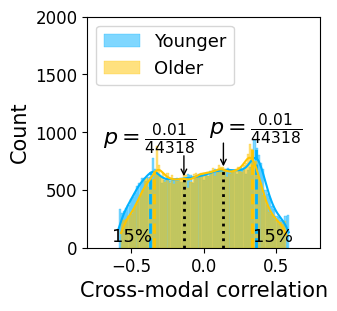

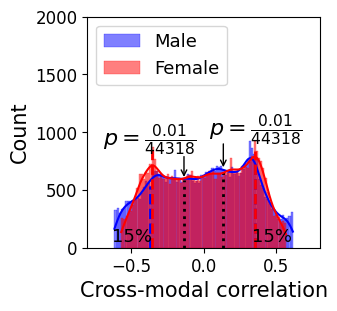

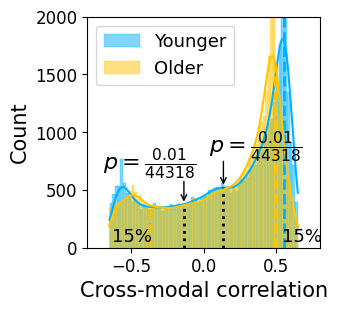

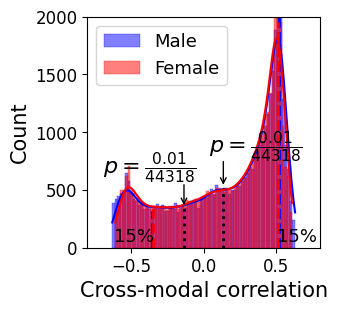

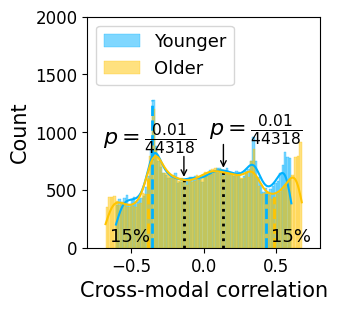

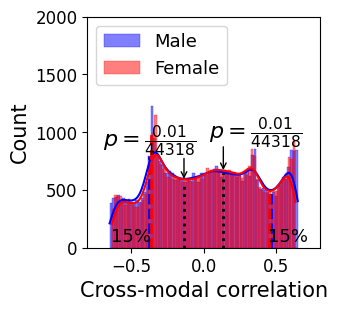

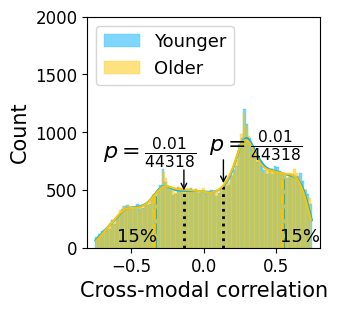

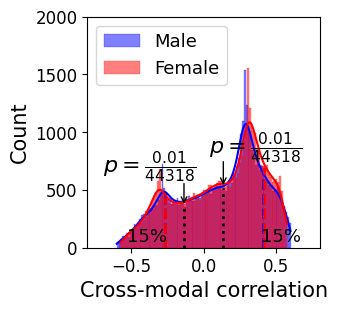

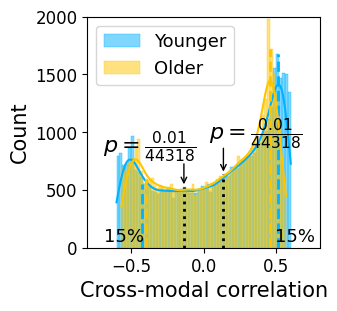

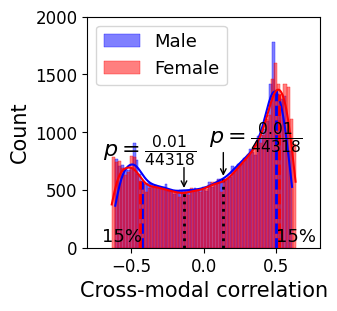

In [ ]:
# AY_corr = sio.loadmat(os.path.join(res_dir, "mat", "AY_group_corr_ukb.mat"))["AY_corr"]
age_median = np.median(age)
n_young = np.sum(age<age_median)
n_old = np.sum(age>=age_median)
n_male = np.sum(sex==0)
n_female = np.sum(sex==1)
n_list = [n_young, n_old, n_male, n_female]

cmap = plt.get_cmap('jet')
percentiles = [30, 70]
norm_percentiles = [p / 100.0 for p in percentiles]
colors = [cmap(norm) for norm in norm_percentiles]

title_list = ["All", "Younger", "Older", "Male", "Female"]
group_list = ["age", "sex"]
color_list = [colors, ["blue", "red"]]

for s in range(5):
    for i, j in enumerate([1,3]):
        fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        pct_neg, pct_pos, h_pct_neg, h_pct_pos = [], [], [], []
        for k in range(2):
            fd = 2*(np.percentile(AY_corr[s,j+k],75) - np.percentile(AY_corr[s,j+k],25))*len(AY_corr[s,j+k])**(-1/3)
            corr_range = np.max(AY_corr[s,j+k]) - np.min(AY_corr[s,j+k])
            num_bins = int(corr_range/(fd/2))
            counts, bins = np.histogram(AY_corr[s,j+k], bins=num_bins)
            hist_plot = sns.histplot(data=AY_corr[s,j+k], bins=num_bins, kde=True, color=color_list[i][k], edgecolor=color_list[i][k], label=title_list[j+k],ax=ax)
            
            pct = np.percentile(AY_corr[s,j+k], [15, 85])
            pct_neg.append(pct[0])
            pct_pos.append(pct[1])
            for q, p in enumerate(pct):
                ind = np.argmin(np.abs(bins - p))
                ax.vlines(p, 0, counts[ind], colors=color_list[i][k], linestyles='dashed', linewidth=2)
                if q == 0:
                    h_pct_neg.append(counts[ind])
                else:
                    h_pct_pos.append(counts[ind])
            
            if k == 0:
                thr_corr = pvalue_to_r(0.01/44318, n_list[j+k-1])
                ind = np.argmin(np.abs(bins - thr_corr))
                ax.vlines(thr_corr, 0, counts[ind], colors='k', linestyles='dotted', linewidth=2)
                ax.text(thr_corr-0.1, counts[ind]+300, "$p=\\frac{0.01}{44318}$", fontsize=16)
                ax.annotate("", xy=(thr_corr, counts[ind]), xytext=(thr_corr, counts[ind]+250), arrowprops=dict(arrowstyle="->"))

                ind = np.argmin(np.abs(bins + thr_corr))
                ax.vlines(-thr_corr, 0, counts[ind], colors='k', linestyles='dotted', linewidth=2)
                ax.text(-thr_corr-0.56, counts[ind]+300, "$p=\\frac{0.01}{44318}$", fontsize=16)
                ax.annotate("", xy=(-thr_corr, counts[ind]), xytext=(-thr_corr, counts[ind]+225), arrowprops=dict(arrowstyle="->"))

        ax.text(min(pct_neg)-0.26, 50, "15%", fontsize=13)
        ax.text(max(pct_pos)-0.02, 50, "15%", fontsize=13)
        
        # ax.set_title(f"Subspace {s+1}", fontsize=16)
        ax.set_xlabel("Cross-modal correlation", fontsize=15)
        ax.set_ylabel("Count", fontsize=15)
        ax.set_xlim([-0.8, 0.8])
        ax.set_ylim([0, 2000])
        ax.legend(loc="upper left", fontsize=13) # bbox_to_anchor=(1.3, 0.25)
        plt.tick_params(axis='both', labelsize=12)
        plt.savefig(f"figures/AY_histogram/ukb/subspace{s+1}_{group_list[i]}.png", bbox_inches="tight", dpi=500)

In [14]:
age_median = np.median(age)
AY_corr = np.zeros((5, 5, 44318))
p_value = np.zeros((5, 5, 44318))
for s, i in enumerate(np.arange(0,10,2)):
    A1 = A[1,1,0,:,i:i+2]
    Y1 = Y[1,1,0,i:i+2]
    A2 = A[1,1,1,:,i:i+2]
    Y2 = Y[1,1,1,i:i+2]
    AY1 = A1@Y1
    AY2 = A2@Y2
    for j in range(44318):
        AY_corr[s,0,j], p_value[s,0,j] = pearsonr(AY1[j], AY2[j])
        AY_corr[s,1,j], p_value[s,1,j] = pearsonr(AY1[j,(age<age_median)&(sex==0)], AY2[j,(age<age_median)&(sex==0)])
        AY_corr[s,2,j], p_value[s,2,j] = pearsonr(AY1[j,(age<age_median)&(sex==1)], AY2[j,(age<age_median)&(sex==1)])
        AY_corr[s,3,j], p_value[s,3,j] = pearsonr(AY1[j,(age>=age_median)&(sex==0)], AY2[j,(age>=age_median)&(sex==0)])
        AY_corr[s,4,j], p_value[s,4,j] = pearsonr(AY1[j,(age>=age_median)&(sex==1)], AY2[j,(age>=age_median)&(sex==1)])
# sio.savemat(os.path.join(res_dir, "mat", "AY_group_corr_ukb_interaction.mat"), {"AY_corr": AY_corr})
# sio.savemat(os.path.join(res_dir, "mat", "AY_group_pvalue_ukb_interaction.mat"), {"p_value": p_value})

In [15]:
Xpath = os.path.join(res_dir, "mat", "sMRI-fMRI", "X_ukb.mat")
X = sio.loadmat(Xpath)['X']
X = np.squeeze(X)
X.shape

(2,)

In [16]:
AY_corr = np.zeros((5, 44318))
for m in range(2):
    Xm = X[m]
    Xm_demean = Xm - np.mean(Xm)
    sstot = np.sum(Xm_demean**2)
    for s, i in enumerate(np.arange(0,10,2)):
        Am = A[1,1,m,:,i:i+2]
        Ym = Y[1,1,m,i:i+2]
        AYm = Am@Ym
        ssres = np.sum((Xm-AYm)**2)
        r2 = (1 - ssres/sstot)*100
        print(f"modality {m+1} subspace {s+1} variance explained: {r2:.3f}%")

modality 1 subspace 1 variance explained: 5.396%
modality 1 subspace 2 variance explained: 7.322%
modality 1 subspace 3 variance explained: 7.011%
modality 1 subspace 4 variance explained: 5.112%
modality 1 subspace 5 variance explained: 7.064%
modality 2 subspace 1 variance explained: 4.995%
modality 2 subspace 2 variance explained: 2.762%
modality 2 subspace 3 variance explained: 3.251%
modality 2 subspace 4 variance explained: 6.445%
modality 2 subspace 5 variance explained: 2.379%


In [17]:
def compute_coefficient_of_variation(m, i=8):
    Am = A[1,1,m,:,i:i+2]
    Ym = Y[1,1,m,i:i+2]
    AYm = Am@Ym
    AYm_std = np.std(AYm, axis=1)
    AYm_young = AYm[:,age<age_median]
    AYm_old = AYm[:,age>=age_median]
    AYm_young_median = hd.geomedian(AYm_young, axis=1)
    AYm_old_median = hd.geomedian(AYm_old, axis=1)
    group_diff = np.abs(np.array(AYm_young_median) - np.array(AYm_old_median))
    coeff_var = group_diff/AYm_std
    return coeff_var

coeff_var1 = compute_coefficient_of_variation(0)
coeff_var2 = compute_coefficient_of_variation(1)
coeff_var = np.maximum(coeff_var1, coeff_var2)
# sio.savemat("mat/AY5_coeff_var_ukb.mat", {"coeff_var": coeff_var})